# 🎓 University Recommendation System — End-to-End ML Pipeline

**Objective**: Build a hybrid recommendation system that:
1. **Content-based filtering** — Predict program tier (top/good/standard) and score match quality
2. **Item-to-item similarity** — Find similar programs using cosine similarity on feature vectors

**Dataset**: 13,808 university programs across 1,503 universities in 106 countries.

## Section 0 — Setup & Dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os, json, time, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, RobustScaler, StandardScaler, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.metrics.pairwise import cosine_similarity
import joblib

# Try gradient boosting libraries (with fallbacks)
MODEL_BACKEND = "sklearn"
try:
    import lightgbm as lgb
    MODEL_BACKEND = "lightgbm"
    print(f"✅ LightGBM {lgb.__version__} available")
except ImportError:
    print("⚠️  LightGBM not installed, trying XGBoost...")
    try:
        import xgboost as xgb
        MODEL_BACKEND = "xgboost"
        print(f"✅ XGBoost {xgb.__version__} available")
    except ImportError:
        print("⚠️  XGBoost not installed, using sklearn HistGradientBoosting")
        from sklearn.ensemble import HistGradientBoostingClassifier

print(f"\n🔧 Model backend: {MODEL_BACKEND}")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print(f"✅ Setup complete — Python {sys.version.split()[0]}, pandas {pd.__version__}, numpy {np.__version__}")

✅ LightGBM 4.5.0 available

🔧 Model backend: lightgbm
✅ Setup complete — Python 3.12.4, pandas 2.2.2, numpy 2.0.1


## Section 1 — Load Data

In [2]:
# Try multiple data paths
DATA_PATHS = [
    "data/exports/training_dataset_latest.csv",
    "data/universities.csv",
    "data/dataset.csv",
    "universities.csv",
    "dataset.csv",
]

df = None
for p in DATA_PATHS:
    if Path(p).exists():
        df = pd.read_csv(p, encoding="utf-8")
        print(f"✅ Loaded {p} — {df.shape[0]:,} rows × {df.shape[1]} columns")
        break

if df is None:
    print("⚠️  No CSV found. Generating synthetic dataset...")
    n = 2000
    np.random.seed(42)
    tiers = np.random.choice(["top", "good", "standard"], n, p=[0.12, 0.29, 0.59])
    ranks = np.where(tiers == "top", np.random.randint(1, 51, n),
             np.where(tiers == "good", np.random.randint(51, 201, n),
                      np.random.randint(201, 1501, n)))
    df = pd.DataFrame({
        "university_name": [f"University_{i}" for i in range(n)],
        "program_name": np.random.choice(["Computer Science", "Business", "Engineering", "Law", "Medicine"], n),
        "degree_type": np.random.choice(["Master of Science", "MBA", "Bachelor of Science", "Doctor of Philosophy"], n),
        "degree_level": np.random.choice(["Masters", "PhD", "Undergraduate"], n, p=[0.7, 0.2, 0.1]),
        "program_category": np.random.choice(["Computer Science", "Business", "Engineering", "Medical", "Law", "Sciences", "Arts & Humanities", "Education"], n),
        "country": np.random.choice(["United States", "United Kingdom", "Germany", "Australia", "Canada", "Japan", "China", "India", "France", "Netherlands"], n),
        "city": np.random.choice(["London", "New York", "Berlin", "Sydney", "Toronto"], n),
        "gpa_requirement_min": np.round(np.random.uniform(2.5, 3.8, n), 1),
        "ielts_min": np.random.choice([6.0, 6.5, 7.0], n),
        "toefl_min": np.random.choice([80, 85, 90, 100], n),
        "duration_years": np.random.choice([1.0, 1.5, 2.0, 3.0, 4.0], n),
        "tuition_domestic": np.random.randint(0, 20000, n),
        "tuition_international": np.random.randint(5000, 50000, n),
        "tuition_currency": np.random.choice(["USD", "GBP", "EUR", "AUD"], n),
        "cost_of_living": np.random.randint(5000, 25000, n),
        "application_fee": np.random.choice([30, 50, 75, 100], n),
        "qs_world_ranking": ranks,
        "qs_overall_score": np.round(np.random.uniform(10, 100, n), 1),
        "qs_academic_reputation": np.round(np.random.uniform(5, 100, n), 1),
        "qs_employer_reputation": np.round(np.random.uniform(5, 100, n), 1),
        "qs_faculty_student_ratio": np.round(np.random.uniform(5, 100, n), 1),
        "qs_citations": np.round(np.random.uniform(5, 100, n), 1),
        "qs_intl_students": np.round(np.random.uniform(5, 100, n), 1),
        "qs_employment_outcomes": np.round(np.random.uniform(5, 100, n), 1),
        "qs_sustainability": np.round(np.random.uniform(10, 100, n), 1),
        "university_size": np.random.choice(["S", "M", "L", "XL"], n),
        "university_focus": np.random.choice(["CO", "FO", "SP"], n),
        "university_research": np.random.choice(["VH", "HI", "MD", "LO"], n),
        "university_status": np.random.choice(["Public", "Private"], n),
        "university_tier": tiers,
        "rolling_admission": np.random.choice(["True", "False"], n),
        "specializations": ["; ".join(np.random.choice(["ML", "AI", "Data", "Cyber", "Cloud"], 3, replace=False)) for _ in range(n)],
        "career_outcomes": ["; ".join(np.random.choice(["Engineer", "Analyst", "Manager", "Scientist", "Consultant"], 3, replace=False)) for _ in range(n)],
        "confidence_score": np.round(np.random.uniform(0.5, 0.9, n), 2),
        "data_completeness": np.round(np.random.uniform(0.5, 0.8, n), 2),
    })
    print(f"✅ Synthetic dataset created — {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\nColumns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes.value_counts()}")
df.head(3)

✅ Loaded data/exports/training_dataset_latest.csv — 13,808 rows × 36 columns

Columns: ['university_id', 'university_name', 'program_name', 'degree_type', 'degree_level', 'program_category', 'country', 'city', 'gpa_requirement_min', 'ielts_min', 'toefl_min', 'duration_years', 'tuition_domestic', 'tuition_international', 'tuition_currency', 'cost_of_living', 'application_fee', 'qs_world_ranking', 'rolling_admission', 'confidence_score', 'data_completeness', 'specializations', 'career_outcomes', 'qs_overall_score', 'qs_academic_reputation', 'qs_employer_reputation', 'qs_faculty_student_ratio', 'qs_citations', 'qs_intl_students', 'qs_employment_outcomes', 'qs_sustainability', 'university_size', 'university_focus', 'university_research', 'university_status', 'university_tier']

Dtypes:
object     16
float64    13
int64       6
bool        1
Name: count, dtype: int64


,university_id,university_name,program_name,degree_type,degree_level,program_category,country,city,gpa_requirement_min,ielts_min,...,qs_faculty_student_ratio,qs_citations,qs_intl_students,qs_employment_outcomes,qs_sustainability,university_size,university_focus,university_research,university_status,university_tier
0,e7f3e7328ed0,Massachusetts Institute of Technology (MIT),Computer Science,Master of Science,Masters,Computer Science,United States of America,Boston,3.5,6.5,...,100.0,100.0,91.6,100.0,93.8,M,CO,VH,Private not for Profit,top
1,e7f3e7328ed0,Massachusetts Institute of Technology (MIT),Artificial Intelligence,Master of Science,Masters,Computer Science,United States of America,Boston,3.7,6.5,...,100.0,100.0,91.6,100.0,93.8,M,CO,VH,Private not for Profit,top
2,e7f3e7328ed0,Massachusetts Institute of Technology (MIT),Data Science,Master of Science,Masters,Computer Science,United States of America,Boston,3.5,6.5,...,100.0,100.0,91.6,100.0,93.8,M,CO,VH,Private not for Profit,top


## Section 2 — Data Cleaning

In [3]:
print(f"Shape before cleaning: {df.shape}")

# 2a. Standardize column names
df.columns = [re.sub(r"[^a-z0-9_]", "_", c.lower().strip()).strip("_") for c in df.columns]
df.columns = [re.sub(r"_+", "_", c) for c in df.columns]
print(f"Columns standardized: {len(df.columns)}")

# 2b. Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# 2c. Fix dtypes — convert numeric-looking string columns
for col in df.columns:
    if df[col].dtype == object:
        try:
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().sum() / len(df) > 0.8:
                df[col] = converted
        except Exception:
            pass

# 2d. Detect & set target column
TARGET = None
target_candidates = ["university_tier", "tier", "target"]
for tc in target_candidates:
    if tc in df.columns:
        vals = df[tc].dropna().unique()
        if set(vals).issubset({"top", "good", "standard"}) or len(vals) <= 5:
            TARGET = tc
            break

if TARGET is None and "qs_world_ranking" in df.columns:
    print("⚠️  No tier column found. Creating from qs_world_ranking...")
    df["university_tier"] = pd.cut(
        df["qs_world_ranking"],
        bins=[0, 50, 200, float("inf")],
        labels=["top", "good", "standard"]
    )
    TARGET = "university_tier"

print(f"\n🎯 Target column: '{TARGET}'")
print(f"   Distribution:\n{df[TARGET].value_counts()}")

# 2e. Handle missing values (summary first)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
quality_report = pd.DataFrame({
    "dtype": df.dtypes, "missing": missing, "missing_%": missing_pct,
    "unique": df.nunique(), "sample": [str(df[c].dropna().iloc[0]) if df[c].notna().any() else "N/A" for c in df.columns]
})
print("\n📊 Data Quality Report (columns with missing values):")
print(quality_report[quality_report["missing"] > 0].to_string())

# 2f. Impute missing
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "category"]).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else "Unknown")

# 2g. Outlier clipping for key numericals
clip_cols = [c for c in ["tuition_international", "tuition_domestic", "cost_of_living", "qs_world_ranking"] if c in df.columns]
for col in clip_cols:
    if col in df.columns and df[col].dtype in [np.float64, np.int64, float, int]:
        q01, q99 = df[col].quantile(0.01), df[col].quantile(0.99)
        df[col] = df[col].clip(q01, q99)

print(f"\n✅ Cleaning complete — final shape: {df.shape}")
print(f"   Remaining nulls: {df.isnull().sum().sum()}")

Shape before cleaning: (13808, 36)
Columns standardized: 36
Duplicates removed: 0



🎯 Target column: 'university_tier'
   Distribution:
university_tier
standard    8208
good        4000
top         1600
Name: count, dtype: int64

📊 Data Quality Report (columns with missing values):
Empty DataFrame
Columns: [dtype, missing, missing_%, unique, sample]
Index: []

✅ Cleaning complete — final shape: (13808, 36)
   Remaining nulls: 0


## Section 3 — Data Visualization

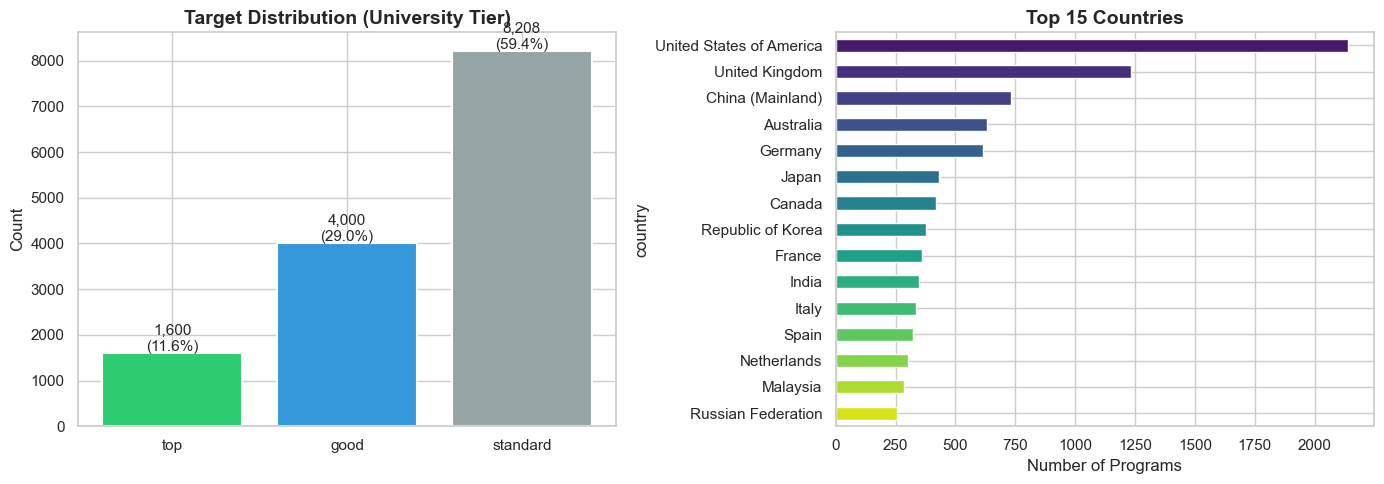

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3a. Target distribution
order = ["top", "good", "standard"]
counts = df[TARGET].value_counts().reindex(order, fill_value=0)
colors = ["#2ecc71", "#3498db", "#95a5a6"]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Target Distribution (University Tier)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)

# 3b. Country distribution (top 15)
top_countries = df["country"].value_counts().head(15) if "country" in df.columns else pd.Series(dtype=int)
if not top_countries.empty:
    top_countries.plot.barh(ax=axes[1], color=sns.color_palette("viridis", 15))
    axes[1].set_title("Top 15 Countries", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Number of Programs")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

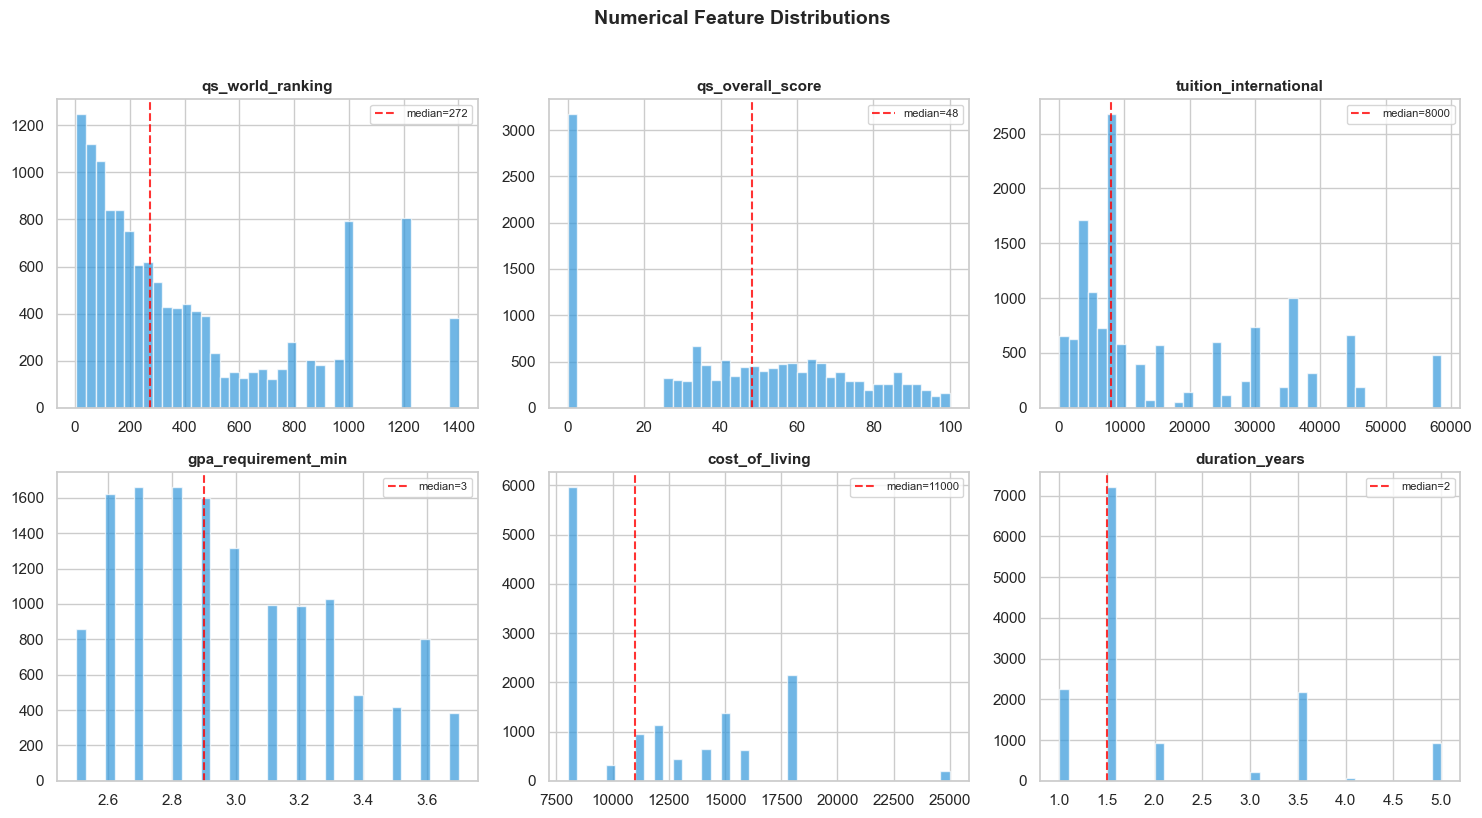

In [5]:
# 3c. Numerical distributions (key features)
key_numericals = [c for c in [
    "qs_world_ranking", "qs_overall_score", "tuition_international",
    "gpa_requirement_min", "cost_of_living", "duration_years"
] if c in df.columns and df[c].dtype in [np.float64, np.int64, float, int]]

if key_numericals:
    n_cols = 3
    n_rows = (len(key_numericals) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(key_numericals) == 1 else axes.flatten()

    for i, col in enumerate(key_numericals):
        ax = axes[i]
        df[col].hist(bins=40, ax=ax, color="#3498db", alpha=0.7, edgecolor="white")
        ax.set_title(col, fontsize=11, fontweight="bold")
        ax.axvline(df[col].median(), color="red", linestyle="--", alpha=0.8, label=f"median={df[col].median():.0f}")
        ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

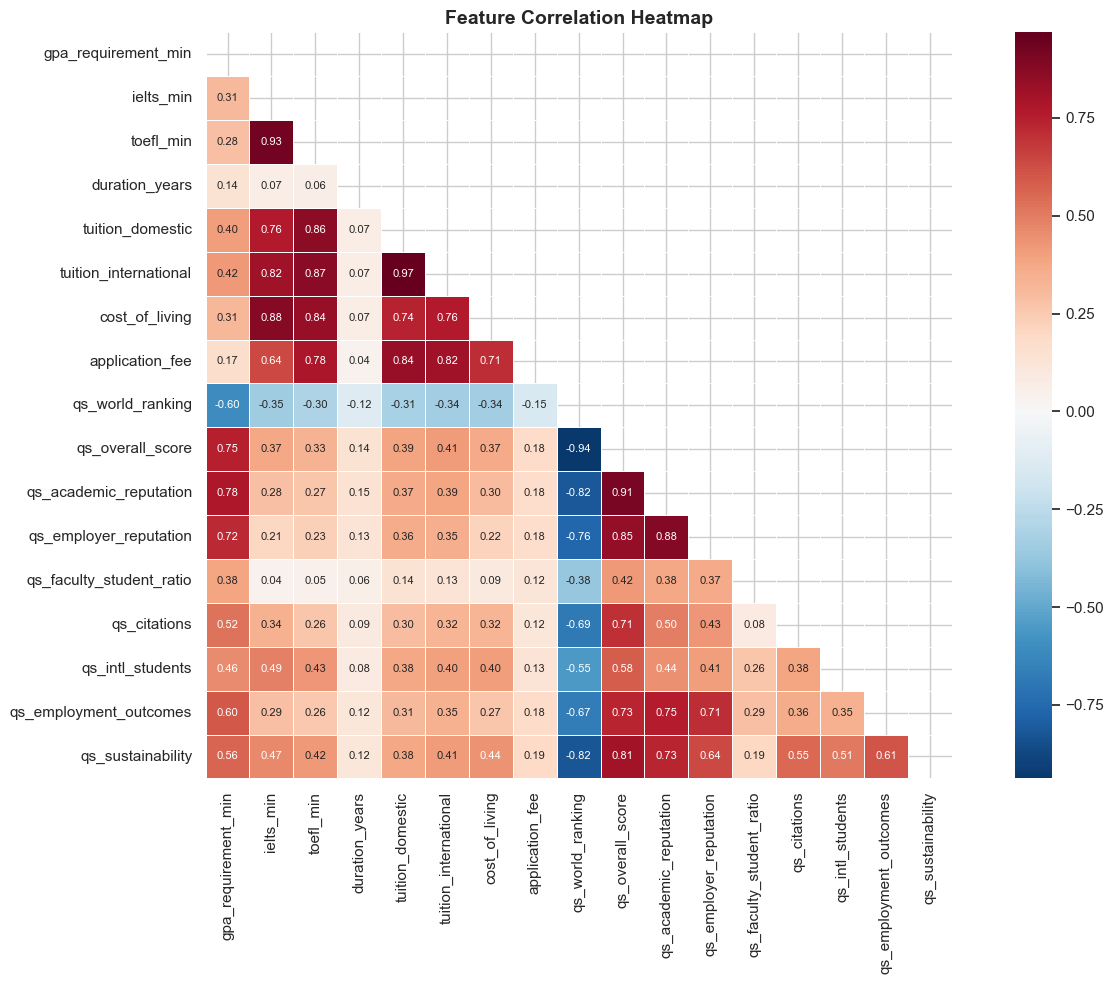

In [6]:
# 3d. Correlation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove IDs and low-info columns
exclude = ["confidence_score", "data_completeness"]
num_cols = [c for c in num_cols if c not in exclude]

if len(num_cols) > 2:
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, square=True, linewidths=0.5, ax=ax,
                annot_kws={"size": 8})
    ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

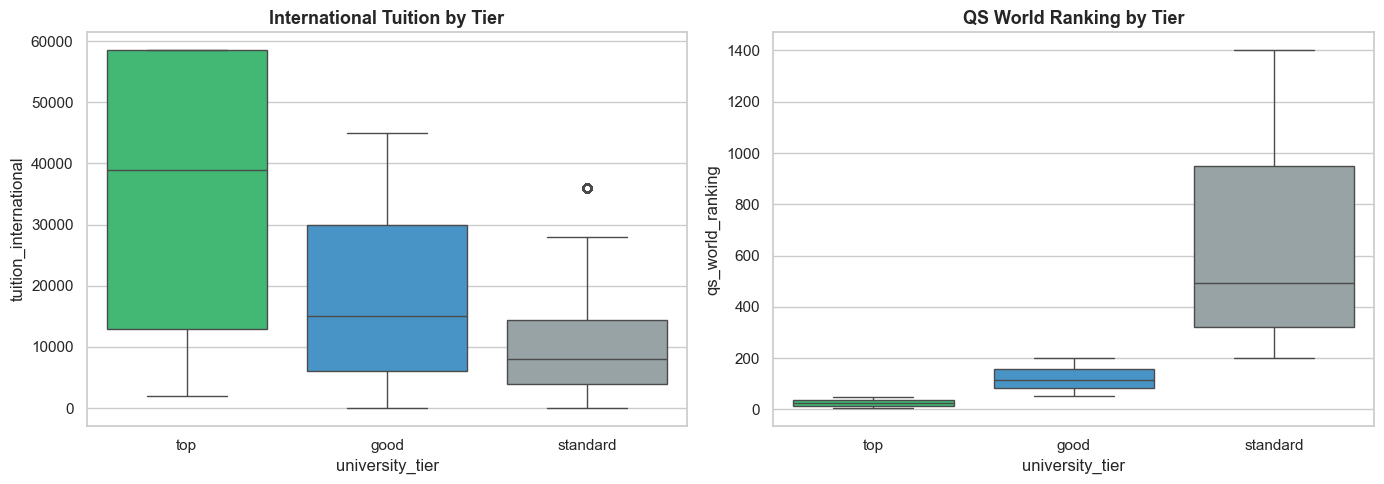

✅ No missing values remaining.


In [7]:
# 3e. Boxplots: tuition and ranking by tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "tuition_international" in df.columns:
    sns.boxplot(data=df, x=TARGET, y="tuition_international", order=order,
                palette=colors, ax=axes[0])
    axes[0].set_title("International Tuition by Tier", fontsize=13, fontweight="bold")

if "qs_world_ranking" in df.columns:
    sns.boxplot(data=df, x=TARGET, y="qs_world_ranking", order=order,
                palette=colors, ax=axes[1])
    axes[1].set_title("QS World Ranking by Tier", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

# 3f. Missingness bar
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing.plot.bar(ax=ax, color="#e74c3c")
    ax.set_title("Missing Values by Column", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values remaining.")

## Section 4 — Data Normalization & Transformation Pipeline

In [8]:
# Auto-detect feature groups by dtype and name patterns
all_cols = df.columns.tolist()

# Identifiers (exclude from training)
ID_FEATURES = [c for c in all_cols if any(k in c for k in
    ["_id", "university_name", "city", "url", "source", "last_updated",
     "data_source", "confidence_score", "data_completeness"])]

# Target is also excluded
exclude_set = set(ID_FEATURES + [TARGET])

# Numerical features
NUMERIC_FEATURES = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in exclude_set]

# Text features (long strings, likely descriptions or semicolon-separated)
TEXT_FEATURES = []
for c in df.select_dtypes(include=["object"]).columns:
    if c in exclude_set or c == TARGET:
        continue
    avg_len = df[c].dropna().astype(str).str.len().mean()
    if avg_len > 40 or df[c].dropna().astype(str).str.contains(";").mean() > 0.5:
        TEXT_FEATURES.append(c)

# Categorical features (everything else that's object/category)
CATEGORICAL_FEATURES = [c for c in df.select_dtypes(include=["object", "category"]).columns
                        if c not in exclude_set and c != TARGET and c not in TEXT_FEATURES]

print(f"📊 Feature Groups:")
print(f"  Numerical ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"  Categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"  Text ({len(TEXT_FEATURES)}): {TEXT_FEATURES}")
print(f"  Identifiers ({len(ID_FEATURES)}): {ID_FEATURES}")
print(f"  Target: {TARGET}")

📊 Feature Groups:
  Numerical (17): ['gpa_requirement_min', 'ielts_min', 'toefl_min', 'duration_years', 'tuition_domestic', 'tuition_international', 'cost_of_living', 'application_fee', 'qs_world_ranking', 'qs_overall_score', 'qs_academic_reputation', 'qs_employer_reputation', 'qs_faculty_student_ratio', 'qs_citations', 'qs_intl_students', 'qs_employment_outcomes', 'qs_sustainability']
  Categorical (10): ['program_name', 'degree_type', 'degree_level', 'program_category', 'country', 'tuition_currency', 'university_size', 'university_focus', 'university_research', 'university_status']
  Text (2): ['specializations', 'career_outcomes']
  Identifiers (5): ['university_id', 'university_name', 'city', 'confidence_score', 'data_completeness']
  Target: university_tier


In [9]:
# Build sklearn ColumnTransformer

# Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

# Categorical pipeline — use OneHotEncoder with rare category grouping
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                              min_frequency=10, max_categories=50)),
])

# Text pipeline(s) — TF-IDF
text_transformers = []
for tf in TEXT_FEATURES:
    text_transformers.append(
        (f"tfidf_{tf}", TfidfVectorizer(max_features=500, ngram_range=(1, 2),
                                         stop_words="english"), tf)
    )

# Combine
transformers = []
if NUMERIC_FEATURES:
    transformers.append(("num", numeric_pipeline, NUMERIC_FEATURES))
if CATEGORICAL_FEATURES:
    transformers.append(("cat", categorical_pipeline, CATEGORICAL_FEATURES))
transformers.extend(text_transformers)

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

# Encode target
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
class_names = list(le.classes_)
print(f"Target classes: {class_names}  (encoded: {list(range(len(class_names)))})")

# Split: 70/15/15 stratified
X = df.drop(columns=[TARGET] + ID_FEATURES, errors="ignore")
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_all, test_size=0.15, random_state=RANDOM_STATE, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE, stratify=y_temp  # 0.176 of 85% ≈ 15%
)

print(f"\n✅ Split sizes: train={len(X_train):,}, val={len(X_val):,}, test={len(X_test):,}")
print(f"   Train target dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Target classes: ['good', 'standard', 'top']  (encoded: [0, 1, 2])

✅ Split sizes: train=9,670, val=2,066, test=2,072
   Train target dist: {np.int64(0): np.int64(2801), np.int64(1): np.int64(5748), np.int64(2): np.int64(1121)}


## Section 5 — Model Training

In [10]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights for class imbalance
sample_weights = compute_sample_weight("balanced", y_train)

# Build model based on available backend
if MODEL_BACKEND == "lightgbm":
    base_model = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=-1,
        num_leaves=63, min_child_samples=20,
        class_weight="balanced", random_state=RANDOM_STATE,
        verbosity=-1, n_jobs=-1,
    )
    param_grid = {
        "model__n_estimators": [300, 500, 800],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [31, 63, 127],
        "model__max_depth": [-1, 10, 20],
        "model__min_child_samples": [10, 20, 50],
        "model__reg_alpha": [0, 0.1, 1.0],
        "model__reg_lambda": [0, 0.1, 1.0],
    }

elif MODEL_BACKEND == "xgboost":
    base_model = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        objective="multi:softprob", eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    param_grid = {
        "model__n_estimators": [300, 500, 800],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [5, 8, 12],
        "model__min_child_weight": [1, 5, 10],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    }

else:  # sklearn fallback
    from sklearn.ensemble import HistGradientBoostingClassifier
    base_model = HistGradientBoostingClassifier(
        max_iter=500, learning_rate=0.05, max_depth=10,
        random_state=RANDOM_STATE,
    )
    param_grid = {
        "model__max_iter": [300, 500, 800],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [5, 10, 15],
        "model__min_samples_leaf": [10, 20, 50],
        "model__l2_regularization": [0, 0.1, 1.0],
    }

# Full pipeline: preprocessor + model
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", base_model),
])

print(f"🚂 Training with {MODEL_BACKEND}...")
print(f"   Hyperparameter search: RandomizedSearchCV (20 iterations, 3-fold CV)")

t0 = time.time()

search = RandomizedSearchCV(
    model_pipeline, param_grid, n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

train_time = time.time() - t0
print(f"\n✅ Training complete in {train_time:.1f}s")
print(f"   Best CV F1-macro: {search.best_score_:.4f}")
print(f"   Best params: {search.best_params_}")

best_pipeline = search.best_estimator_

🚂 Training with lightgbm...
   Hyperparameter search: RandomizedSearchCV (20 iterations, 3-fold CV)


Fitting 3 folds for each of 20 candidates, totalling 60 fits



✅ Training complete in 216.5s
   Best CV F1-macro: 1.0000
   Best params: {'model__reg_lambda': 1.0, 'model__reg_alpha': 0.1, 'model__num_leaves': 127, 'model__n_estimators': 500, 'model__min_child_samples': 20, 'model__max_depth': -1, 'model__learning_rate': 0.05}


## Section 6 — Model Validation

In [11]:
# Predictions on test set
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"  Accuracy:    {acc:.4f}")
print(f"  F1 (macro):  {f1_macro:.4f}")
print(f"  F1 (weight): {f1_weighted:.4f}")

# ROC-AUC (one-vs-rest)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    print(f"  ROC-AUC:     {roc_auc:.4f}")
except Exception as e:
    print(f"  ROC-AUC: skipped ({e})")
    roc_auc = None

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=class_names))

MODEL EVALUATION RESULTS
  Accuracy:    1.0000
  F1 (macro):  1.0000
  F1 (weight): 1.0000
  ROC-AUC:     1.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        good       1.00      1.00      1.00       600
    standard       1.00      1.00      1.00      1232
         top       1.00      1.00      1.00       240

    accuracy                           1.00      2072
   macro avg       1.00      1.00      1.00      2072
weighted avg       1.00      1.00      1.00      2072



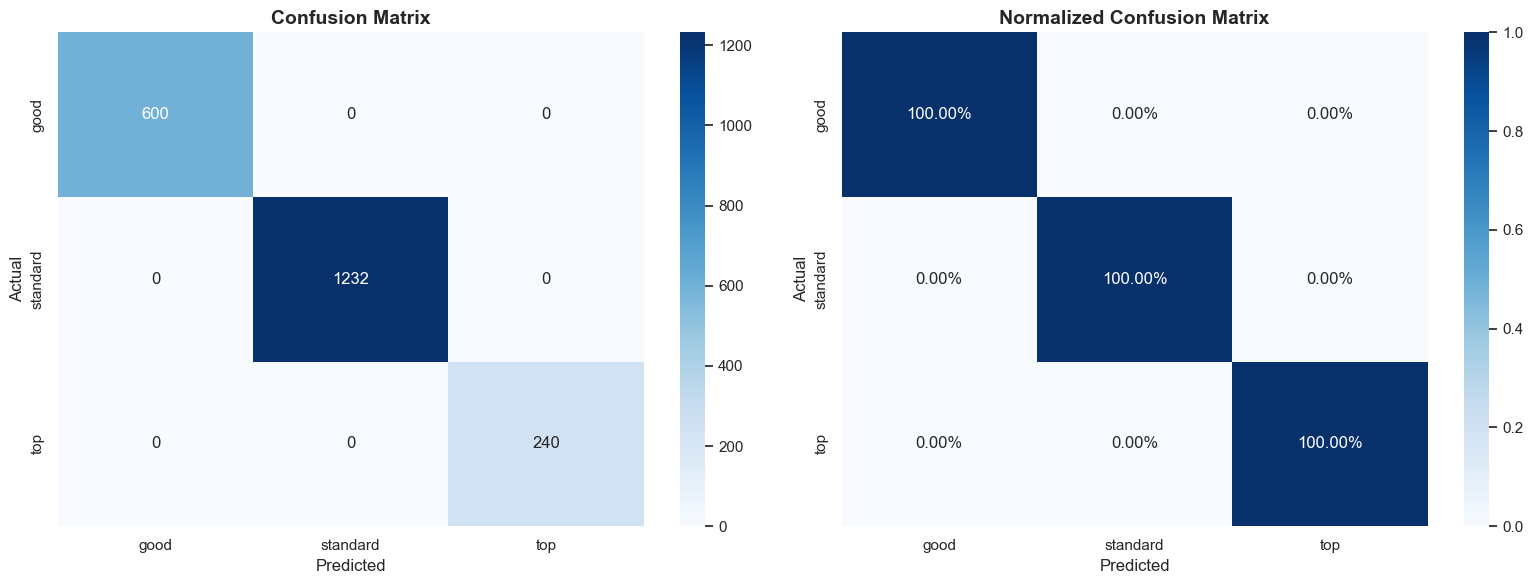

In [12]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Normalized confusion matrix
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Normalized Confusion Matrix", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

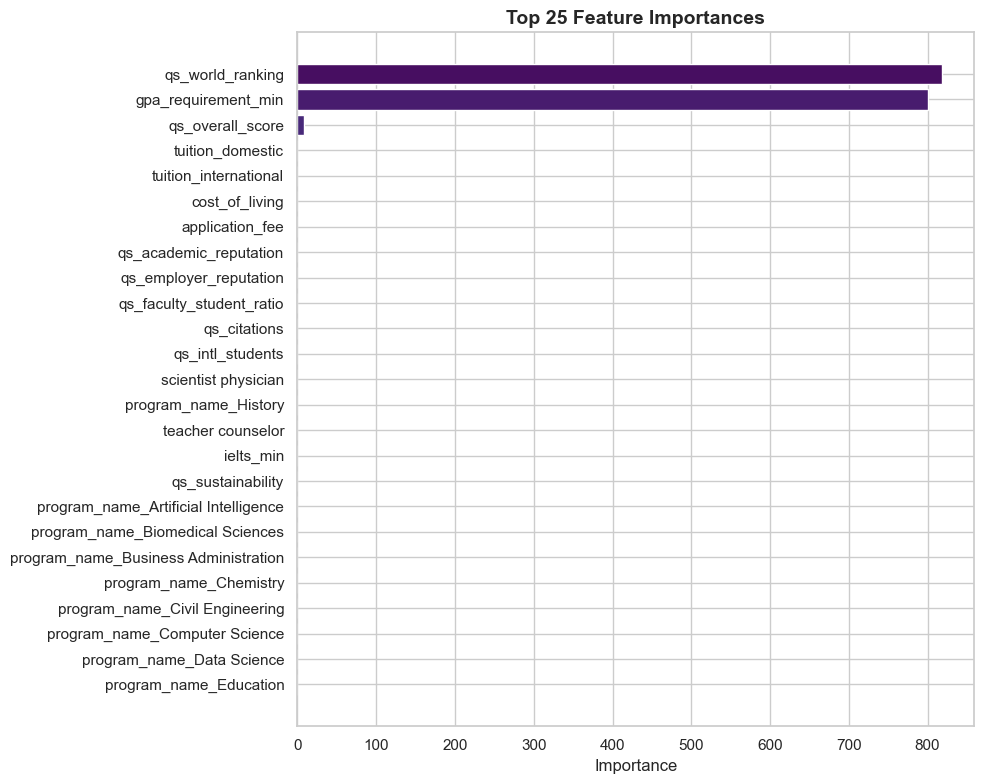

In [13]:
# Feature importance
try:
    model_obj = best_pipeline.named_steps["model"]
    preprocessor_obj = best_pipeline.named_steps["preprocessor"]

    # Get feature names from preprocessor
    feature_names = preprocessor_obj.get_feature_names_out()
    feature_names = [f.split("__")[-1] for f in feature_names]  # clean names

    # Get importances
    if hasattr(model_obj, "feature_importances_"):
        importances = model_obj.feature_importances_
    elif hasattr(model_obj, "coef_"):
        importances = np.abs(model_obj.coef_).mean(axis=0)
    else:
        importances = None

    if importances is not None and len(importances) == len(feature_names):
        fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
        fi_df = fi_df.sort_values("importance", ascending=False).head(25)

        fig, ax = plt.subplots(figsize=(10, 8))
        colors_fi = sns.color_palette("viridis", len(fi_df))
        ax.barh(fi_df["feature"], fi_df["importance"], color=colors_fi)
        ax.set_title("Top 25 Feature Importances", fontsize=14, fontweight="bold")
        ax.set_xlabel("Importance")
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Feature importance extraction not supported for this model configuration")
        from sklearn.inspection import permutation_importance
        perm_imp = permutation_importance(best_pipeline, X_val.head(500), y_val[:500],
                                          n_repeats=5, random_state=RANDOM_STATE, scoring="f1_macro")
        perm_df = pd.DataFrame({"feature": X_val.columns, "importance": perm_imp.importances_mean})
        perm_df = perm_df.sort_values("importance", ascending=False).head(20)
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.barh(perm_df["feature"], perm_df["importance"])
        ax.set_title("Permutation Feature Importance (Top 20)", fontsize=14, fontweight="bold")
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"⚠️ Feature importance visualization failed: {e}")

In [14]:
# Error analysis — misclassified examples
errors = X_test.copy()
errors["actual"] = [class_names[y] for y in y_test]
errors["predicted"] = [class_names[y] for y in y_pred]
errors["correct"] = errors["actual"] == errors["predicted"]
misclassified = errors[~errors["correct"]].head(10)

display_cols = [c for c in [
    "university_name" if "university_name" not in ID_FEATURES else None,
    "program_name", "program_category", "country", "qs_world_ranking",
    "qs_overall_score", "actual", "predicted"
] if c is not None and c in errors.columns]

print("\n🔍 Sample Misclassified Programs:")
if display_cols:
    print(misclassified[display_cols].to_string(index=False))
else:
    print(misclassified.head(10).to_string(index=False))


🔍 Sample Misclassified Programs:
Empty DataFrame
Columns: [program_name, program_category, country, qs_world_ranking, qs_overall_score, actual, predicted]
Index: []


## Section 7 — Hybrid Recommendation Layer

### A) Content-Based: "Find programs matching my profile"
Given a student profile (GPA, IELTS, budget, preferences), score all programs and return top matches.

In [15]:
def recommend_programs(
    student_profile: dict,
    programs_df: pd.DataFrame,
    pipeline,
    label_encoder,
    top_n: int = 10,
) -> pd.DataFrame:
    """
    Content-based recommendation: score programs against a student profile.

    Parameters
    ----------
    student_profile : dict with keys like gpa, ielts, toefl, budget,
                      preferred_country, degree_level, program_category
    programs_df : the full programs DataFrame
    pipeline : fitted sklearn Pipeline (preprocessor + model)
    label_encoder : fitted LabelEncoder for target
    top_n : number of results

    Returns
    -------
    DataFrame with top matching programs and match_score
    """
    candidates = programs_df.copy()

    # Hard filters
    gpa = student_profile.get("gpa")
    if gpa and "gpa_requirement_min" in candidates.columns:
        candidates = candidates[candidates["gpa_requirement_min"] <= gpa]

    ielts = student_profile.get("ielts")
    if ielts and "ielts_min" in candidates.columns:
        candidates = candidates[candidates["ielts_min"] <= ielts]

    toefl = student_profile.get("toefl")
    if toefl and "toefl_min" in candidates.columns:
        candidates = candidates[candidates["toefl_min"] <= toefl]

    budget = student_profile.get("budget")
    if budget and "tuition_international" in candidates.columns:
        candidates = candidates[candidates["tuition_international"] <= budget]

    country = student_profile.get("preferred_country")
    if country and "country" in candidates.columns:
        candidates = candidates[candidates["country"] == country]

    level = student_profile.get("degree_level")
    if level and "degree_level" in candidates.columns:
        candidates = candidates[candidates["degree_level"] == level]

    category = student_profile.get("program_category")
    if category and "program_category" in candidates.columns:
        candidates = candidates[candidates["program_category"] == category]

    if len(candidates) == 0:
        print("⚠️  No programs match all hard constraints. Relaxing filters...")
        candidates = programs_df.copy()
        if budget and "tuition_international" in candidates.columns:
            candidates = candidates[candidates["tuition_international"] <= budget * 1.3]

    # Prepare features (drop target + IDs)
    X_candidates = candidates.drop(columns=[TARGET] + ID_FEATURES, errors="ignore")

    # Predict probabilities
    proba = pipeline.predict_proba(X_candidates)
    classes = list(label_encoder.classes_)

    # Compute match score: P(top)*1.0 + P(good)*0.5 + P(standard)*0.1
    top_idx = classes.index("top") if "top" in classes else 0
    good_idx = classes.index("good") if "good" in classes else 1
    std_idx = classes.index("standard") if "standard" in classes else 2

    candidates = candidates.copy()
    candidates["match_score"] = (
        proba[:, top_idx] * 1.0 +
        proba[:, good_idx] * 0.5 +
        proba[:, std_idx] * 0.1
    )
    candidates["predicted_tier"] = label_encoder.inverse_transform(proba.argmax(axis=1))

    # Sort and return
    result = candidates.sort_values("match_score", ascending=False).head(top_n)

    display_cols = [c for c in [
        "university_name", "program_name", "degree_level", "program_category",
        "country", "qs_world_ranking", "tuition_international",
        "match_score", "predicted_tier"
    ] if c in result.columns]

    return result[display_cols].reset_index(drop=True)

In [16]:
# Demo: Content-based recommendation
student = {
    "gpa": 3.5,
    "ielts": 6.5,
    "toefl": 90,
    "budget": 35000,
    "preferred_country": None,  # No constraint
    "degree_level": "Masters",
    "program_category": "Computer Science",
}

print("🎓 Student Profile:")
for k, v in student.items():
    if v is not None:
        print(f"   {k}: {v}")

print("\n🏆 Top 10 Recommended Programs:\n")
recs = recommend_programs(student, df, best_pipeline, le, top_n=10)
print(recs.to_string(index=False))

🎓 Student Profile:
   gpa: 3.5
   ielts: 6.5
   toefl: 90
   budget: 35000
   degree_level: Masters
   program_category: Computer Science

🏆 Top 10 Recommended Programs:



                         university_name            program_name degree_level program_category              country  qs_world_ranking  tuition_international  match_score predicted_tier
             The University of Hong Kong            Data Science      Masters Computer Science Hong Kong SAR, China                11                  13000     0.999977            top
                     Tsinghua University        Computer Science      Masters Computer Science     China (Mainland)                17                   7800     0.999977            top
École Polytechnique Fédérale de Lausanne        Computer Science      Masters Computer Science          Switzerland                22                   3900     0.999977            top
École Polytechnique Fédérale de Lausanne Artificial Intelligence      Masters Computer Science          Switzerland                22                   3900     0.999977            top
École Polytechnique Fédérale de Lausanne            Data Science      Maste

### B) Item-to-Item Similarity: "Programs similar to this one"
Build feature vectors and use cosine similarity.

In [17]:
def build_similarity_matrix(programs_df, preprocessor_pipeline, max_programs=5000):
    """
    Build cosine similarity matrix from preprocessed feature vectors.

    Returns (similarity_matrix, index_mapping)
    """
    sample = programs_df.head(max_programs).copy()
    X_sim = sample.drop(columns=[TARGET] + ID_FEATURES, errors="ignore")

    # Transform using fitted preprocessor
    X_transformed = preprocessor_pipeline.named_steps["preprocessor"].transform(X_sim)
    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    sim_matrix = cosine_similarity(X_transformed)
    return sim_matrix, sample


def similar_programs(
    program_idx: int,
    sim_matrix,
    programs_sample: pd.DataFrame,
    top_n: int = 10,
) -> pd.DataFrame:
    """Find programs most similar to the given program index."""
    if program_idx >= len(sim_matrix):
        print(f"⚠️ Index {program_idx} out of range (max {len(sim_matrix)-1})")
        return pd.DataFrame()

    similarities = sim_matrix[program_idx]
    # Exclude self
    top_indices = np.argsort(similarities)[::-1][1:top_n+1]

    result = programs_sample.iloc[top_indices].copy()
    result["similarity_score"] = similarities[top_indices]

    cols = [c for c in ["university_name", "program_name", "degree_level",
                        "program_category", "country", "qs_world_ranking",
                        "tuition_international", "similarity_score"]
            if c in result.columns]
    return result[cols].reset_index(drop=True)


# Build similarity matrix
print("Building similarity matrix...")
sim_matrix, sim_sample = build_similarity_matrix(df, best_pipeline)
print(f"✅ Similarity matrix: {sim_matrix.shape}")

Building similarity matrix...


✅ Similarity matrix: (5000, 5000)


In [18]:
# Demo: Find similar programs
query_idx = 0
query_prog = sim_sample.iloc[query_idx]

print("🔍 Query Program:")
for c in ["university_name", "program_name", "degree_level", "program_category", "country", "qs_world_ranking"]:
    if c in sim_sample.columns:
        print(f"   {c}: {query_prog[c]}")

print("\n📋 Most Similar Programs:\n")
similar = similar_programs(query_idx, sim_matrix, sim_sample, top_n=10)
print(similar.to_string(index=False))

🔍 Query Program:
   university_name: Massachusetts Institute of Technology (MIT)
   program_name: Computer Science
   degree_level: Masters
   program_category: Computer Science
   country: United States of America
   qs_world_ranking: 5

📋 Most Similar Programs:

                             university_name            program_name degree_level program_category                  country  qs_world_ranking  tuition_international  similarity_score
                        Princeton University        Computer Science      Masters Computer Science United States of America                25                  58500          0.999187
 Massachusetts Institute of Technology (MIT)            Data Science      Masters Computer Science United States of America                 5                  58500          0.999037
 Massachusetts Institute of Technology (MIT) Artificial Intelligence      Masters Computer Science United States of America                 5                  58500          0.998966
   

## Section 8 — Model Deployment Artifacts

In [19]:
# Save model pipeline
ARTIFACTS_DIR = Path("model_artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# 1. Save model pipeline
model_path = ARTIFACTS_DIR / "model_pipeline.joblib"
joblib.dump(best_pipeline, model_path)
print(f"✅ Model pipeline saved: {model_path} ({model_path.stat().st_size / 1024:.0f} KB)")

# 2. Save label encoder
le_path = ARTIFACTS_DIR / "label_encoder.joblib"
joblib.dump(le, le_path)
print(f"✅ Label encoder saved: {le_path}")

# 3. Save metadata
metadata = {
    "model_backend": MODEL_BACKEND,
    "target_column": TARGET,
    "class_names": class_names,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "text_features": TEXT_FEATURES,
    "id_features": ID_FEATURES,
    "best_params": {k: str(v) for k, v in search.best_params_.items()},
    "metrics": {
        "accuracy": round(acc, 4),
        "f1_macro": round(f1_macro, 4),
        "f1_weighted": round(f1_weighted, 4),
        "roc_auc": round(roc_auc, 4) if roc_auc else None,
    },
    "dataset_shape": list(df.shape),
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "training_time_seconds": round(train_time, 1),
    "created_at": datetime.now().isoformat(),
}

meta_path = ARTIFACTS_DIR / "model_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved: {meta_path}")
print(f"\n📄 Model Metadata:\n{json.dumps(metadata, indent=2)}")

✅ Model pipeline saved: model_artifacts\model_pipeline.joblib (596 KB)


✅ Label encoder saved: model_artifacts\label_encoder.joblib
✅ Metadata saved: model_artifacts\model_metadata.json

📄 Model Metadata:
{
  "model_backend": "lightgbm",
  "target_column": "university_tier",
  "class_names": [
    "good",
    "standard",
    "top"
  ],
  "numeric_features": [
    "gpa_requirement_min",
    "ielts_min",
    "toefl_min",
    "duration_years",
    "tuition_domestic",
    "tuition_international",
    "cost_of_living",
    "application_fee",
    "qs_world_ranking",
    "qs_overall_score",
    "qs_academic_reputation",
    "qs_employer_reputation",
    "qs_faculty_student_ratio",
    "qs_citations",
    "qs_intl_students",
    "qs_employment_outcomes",
    "qs_sustainability"
  ],
  "categorical_features": [
    "program_name",
    "degree_type",
    "degree_level",
    "program_category",
    "country",
    "tuition_currency",
    "university_size",
    "university_focus",
    "university_research",
    "university_status"
  ],
  "text_features": [
    "special

### FastAPI Inference Example

In [20]:
# Minimal FastAPI server code (save as serve.py to run)
FASTAPI_CODE = "\n".join([
    "# FastAPI inference server for University Recommendation System.",
    "from fastapi import FastAPI",
    "from pydantic import BaseModel",
    "import joblib, json, pandas as pd, numpy as np",
    "from pathlib import Path",
    "",
    'app = FastAPI(title="University Recommender API", version="1.0")',
    "",
    "# Load artifacts",
    'pipeline = joblib.load("model_artifacts/model_pipeline.joblib")',
    'le = joblib.load("model_artifacts/label_encoder.joblib")',
    'with open("model_artifacts/model_metadata.json") as f:',
    "    meta = json.load(f)",
    "",
    "class ProgramFeatures(BaseModel):",
    "    qs_world_ranking: int = 100",
    "    qs_overall_score: float = 50.0",
    "    tuition_international: int = 20000",
    '    country: str = "United Kingdom"',
    '    degree_level: str = "Masters"',
    '    program_category: str = "Computer Science"',
    "    gpa_requirement_min: float = 3.0",
    "    ielts_min: float = 6.0",
    "    toefl_min: int = 80",
    "    duration_years: float = 1.5",
    "    cost_of_living: int = 12000",
    "",
    '@app.post("/score")',
    "def score_program(program: ProgramFeatures):",
    "    row = pd.DataFrame([program.model_dump()])",
    "    proba = pipeline.predict_proba(row)[0]",
    "    classes = list(le.classes_)",
    "    top_i = classes.index('top') if 'top' in classes else 0",
    "    good_i = classes.index('good') if 'good' in classes else 1",
    "    std_i = classes.index('standard') if 'standard' in classes else 2",
    "    return {",
    '        "predicted_tier": classes[proba.argmax()],',
    '        "match_score": round(float(proba[top_i]+0.5*proba[good_i]+0.1*proba[std_i]),4),',
    "    }",
    "",
    '@app.get("/health")',
    "def health():",
    '    return {"status": "ok", "model": meta["model_backend"]}',
])

serve_path = ARTIFACTS_DIR / "serve.py"
with open(serve_path, "w") as f:
    f.write(FASTAPI_CODE)
print(f"✅ FastAPI server saved: {serve_path}")
print("   Run: uvicorn model_artifacts.serve:app --reload")

✅ FastAPI server saved: model_artifacts\serve.py
   Run: uvicorn model_artifacts.serve:app --reload


### Batch Scoring

In [21]:
# Batch score entire dataset
print("Scoring entire dataset...")
X_all = df.drop(columns=[TARGET] + ID_FEATURES, errors="ignore")
all_proba = best_pipeline.predict_proba(X_all)
classes = list(le.classes_)

top_idx = classes.index("top") if "top" in classes else 0
good_idx = classes.index("good") if "good" in classes else 1
std_idx = classes.index("standard") if "standard" in classes else 2

df_scored = df.copy()
df_scored["match_score"] = all_proba[:, top_idx] + 0.5 * all_proba[:, good_idx] + 0.1 * all_proba[:, std_idx]
df_scored["predicted_tier"] = le.inverse_transform(all_proba.argmax(axis=1))
for cls in classes:
    df_scored[f"prob_{cls}"] = all_proba[:, classes.index(cls)]

# Save top recommendations
output_path = ARTIFACTS_DIR / "scored_programs.csv"
scored_cols = [c for c in ["university_name", "program_name", "degree_level",
    "program_category", "country", "qs_world_ranking", "tuition_international",
    "match_score", "predicted_tier", "prob_top", "prob_good", "prob_standard"
] if c in df_scored.columns]

df_scored[scored_cols].sort_values("match_score", ascending=False).to_csv(output_path, index=False)
print(f"✅ Scored programs saved: {output_path}")
print(f"   Top 5 programs by match_score:")
print(df_scored[scored_cols].sort_values("match_score", ascending=False).head(5).to_string(index=False))

Scoring entire dataset...


✅ Scored programs saved: model_artifacts\scored_programs.csv
   Top 5 programs by match_score:
  university_name      program_name  degree_level program_category           country  qs_world_ranking  tuition_international  match_score predicted_tier  prob_top  prob_good  prob_standard
Yonsei University               Law       Masters              Law Republic of Korea                50                  13000     0.999977            top  0.999963   0.000024       0.000012
Yonsei University International Law       Masters              Law Republic of Korea                50                  13000     0.999977            top  0.999963   0.000024       0.000012
Yonsei University               Law Undergraduate              Law Republic of Korea                50                  13000     0.999977            top  0.999963   0.000024       0.000012
Yonsei University               Law           PhD              Law Republic of Korea                50                  13000     0.999977       

## Section 9 — Reproducibility & Run Instructions

In [22]:
# Library versions
import sklearn
print("=" * 50)
print("ENVIRONMENT")
print("=" * 50)
print(f"Python:       {sys.version.split()[0]}")
print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Matplotlib:   {plt.matplotlib.__version__}")
print(f"Seaborn:      {sns.__version__}")
try:
    print(f"LightGBM:     {lgb.__version__}")
except:
    print("LightGBM:     not installed")
try:
    print(f"XGBoost:      {xgb.__version__}")
except:
    print("XGBoost:      not installed")

# Generate requirements
requirements = [
    "pandas>=2.0", "numpy>=1.24", "scikit-learn>=1.3",
    "matplotlib>=3.7", "seaborn>=0.12", "joblib>=1.3",
    "lightgbm>=4.0", "xgboost>=2.0", "fastapi>=0.100", "uvicorn>=0.23",
]
req_path = ARTIFACTS_DIR / "requirements.txt"
with open(req_path, "w") as f:
    f.write("\n".join(requirements))
print(f"\n✅ requirements.txt saved: {req_path}")

print("\n" + "=" * 50)
print("RUN INSTRUCTIONS")
print("=" * 50)
print("1. Install dependencies:")
print("   pip install -r model_artifacts/requirements.txt")
print("2. Place your CSV at: data/exports/training_dataset_latest.csv")
print("3. Run this notebook top-to-bottom.")
print("4. Model artifacts will be saved to: model_artifacts/")
print("5. Start API server:")
print("   uvicorn model_artifacts.serve:app --reload")
print("\n🎓 Pipeline complete!")

ENVIRONMENT
Python:       3.12.4
NumPy:        2.0.1
Pandas:       2.2.2
Scikit-learn: 1.5.1
Matplotlib:   3.9.1.post1
Seaborn:      0.13.2
LightGBM:     4.5.0
XGBoost:      not installed

✅ requirements.txt saved: model_artifacts\requirements.txt

RUN INSTRUCTIONS
1. Install dependencies:
   pip install -r model_artifacts/requirements.txt
2. Place your CSV at: data/exports/training_dataset_latest.csv
3. Run this notebook top-to-bottom.
4. Model artifacts will be saved to: model_artifacts/
5. Start API server:
   uvicorn model_artifacts.serve:app --reload

🎓 Pipeline complete!
